In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd()

project_root = current_dir.parents[2] 

if str(project_root) not in sys.path:
    
    sys.path.append(str(project_root))

print(f"Project root added: {project_root}")

Project root added: /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn


Extracting /Users/shaique/Desktop/BioInf_IMP/NMM_group/ICML/bcos_gnn/bcosgnn/data/PATTERN/raw/PATTERN_v2.zip
Processing...
Done!


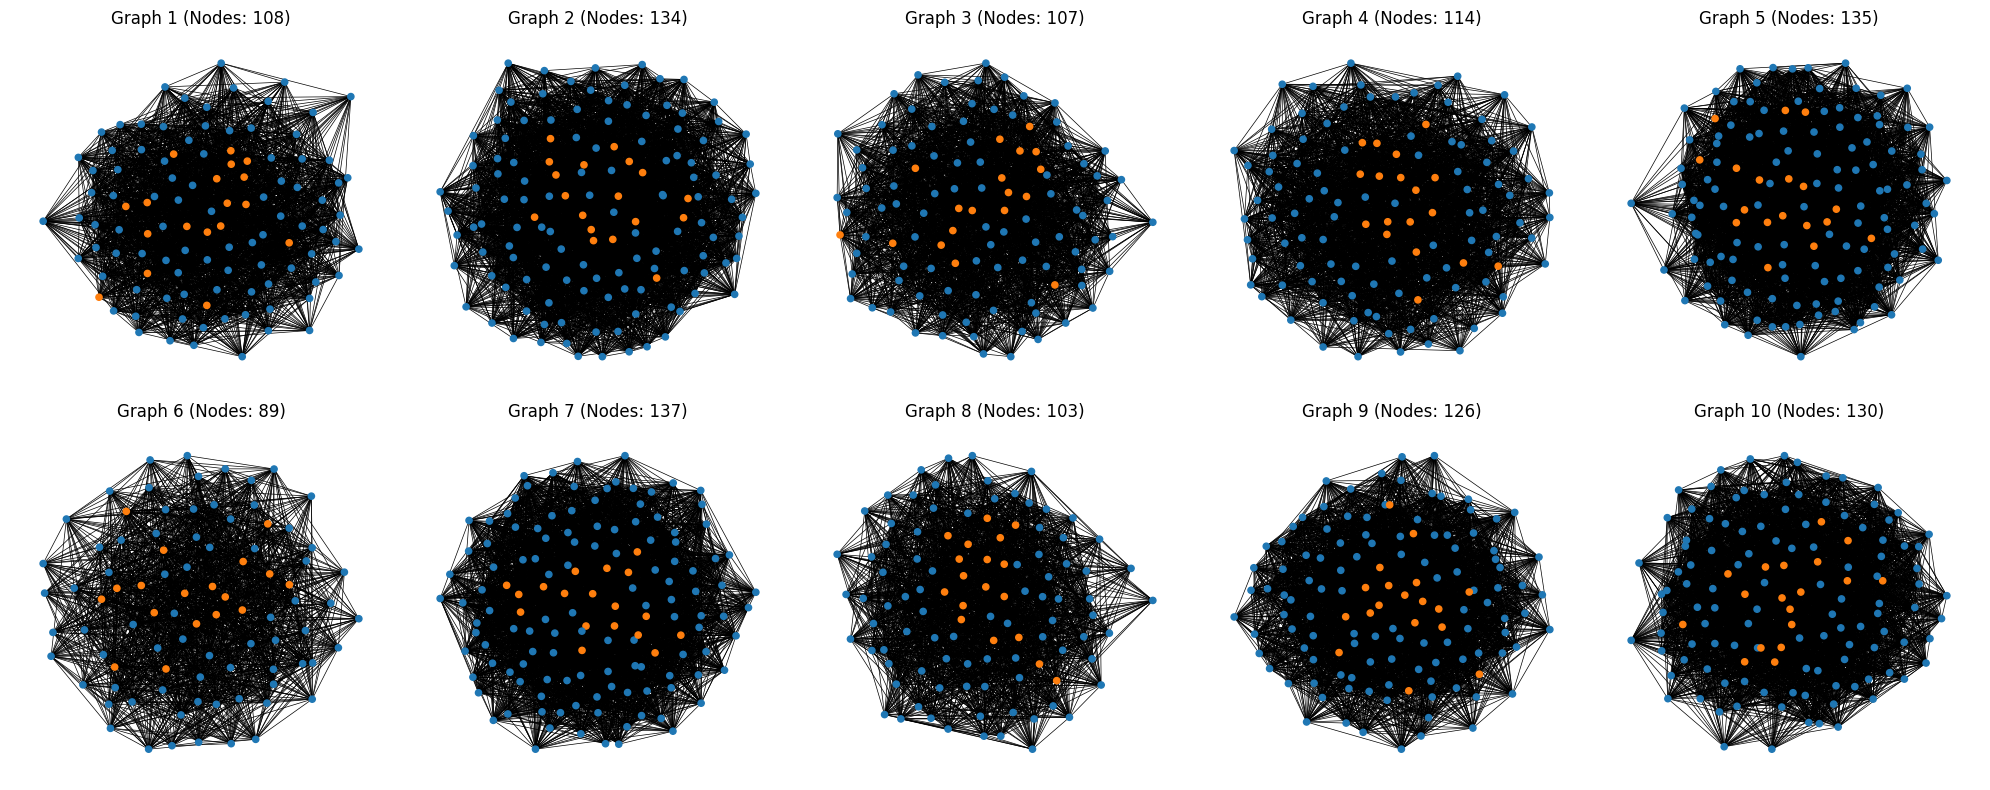

In [13]:
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.datasets import GNNBenchmarkDataset
from torch_geometric.utils import to_networkx
import os

data_dir = os.path.join(project_root, "data/")

# Load dataset
dataset = GNNBenchmarkDataset(root=data_dir, name='PATTERN', split='train')

def visualize_graphs(dataset, num_graphs=10):
    plt.figure(figsize=(20, 8))
    for i in range(num_graphs):
        data = dataset[i]
        # Convert PyG graph to NetworkX for visualization
        G = to_networkx(data, to_undirected=True)
        
        plt.subplot(2, 5, i + 1)
        # Use node labels for coloring: Label 0 (Blue), Label 1 (Orange)
        colors = ['#1f77b4' if l == 0 else '#ff7f0e' for l in data.y.tolist()]
        
        nx.draw(G, node_size=20, node_color=colors, width=0.5, with_labels=False)
        plt.title(f"Graph {i+1} (Nodes: {data.num_nodes})")
    
    plt.tight_layout()
    plt.show()

visualize_graphs(dataset)

In [10]:
import torch.nn.functional as F
from torch.nn import Sequential, Linear, ReLU, BatchNorm1d
from torch_geometric.nn import GINConv, global_add_pool

class GINNodeClassifier(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        
        super(GINNodeClassifier, self).__init__()

        self.conv1 = GINConv(Sequential(Linear(in_channels, hidden_channels) , BatchNorm1d(hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels), ReLU()))

        self.bn1 = BatchNorm1d(hidden_channels)

        self.conv2 = GINConv(Sequential(Linear(hidden_channels, hidden_channels) , BatchNorm1d(hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels), ReLU()))

        self.bn2 = BatchNorm1d(hidden_channels)

        self.conv3 = GINConv(Sequential(Linear(hidden_channels, hidden_channels) , BatchNorm1d(hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels), ReLU()))

        self.bn3 = BatchNorm1d(hidden_channels)

        self.conv4 = GINConv(Sequential(Linear(hidden_channels, hidden_channels) , BatchNorm1d(hidden_channels), ReLU(), Linear(hidden_channels, hidden_channels), ReLU()))

        self.bn4 = BatchNorm1d(hidden_channels)

        self.classifier = Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):

        x = x.floar()

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.conv4(x, edge_index)
        x = self.bn4(x)
        x = F.relu(x)

        return self.classifier(x)

model = GINNodeClassifier(in_channels=dataset.num_features, hidden_channels=64, out_channels=2)
print(model)

GINNodeClassifier(
  (conv1): GINConv(nn=Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  ))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): GINConv(nn=Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  ))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): GINConv(nn=Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=

In [ ]:
train_dataset = GF